In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  72.38632555003366


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 72.38632555003366
calculating stable deltas...
Gamma_ii for m1: 537.3825690964409
Gamma_ii for m1: 537.3825690941823
Gamma_ii for m1: 537.3825691159049
Gamma_ii for m1: 537.3825690940919
Gamma_ii for m1: 537.3825690237794
Gamma_ii for m1: 537.3825700379615
Gamma_ii for m1: 537.382566842265
Gamma_ii for m1: 537.3825584008633
Gamma_ii for m1: 537.3825159225174
Gamma_ii for m1: 537.3826749599328
[np.float64(4.2029952866213975e-12), np.float64(4.0422968810763276e-11), np.float64(4.059115632198604e-11), np.float64(1.3084247799032186e-10), np.float64(1.887262717413514e-09), np.float64(5.946781181642637e-09), np.float64(1.5708365485340814e-08), np.float64(7.904675839881308e-08), np.float

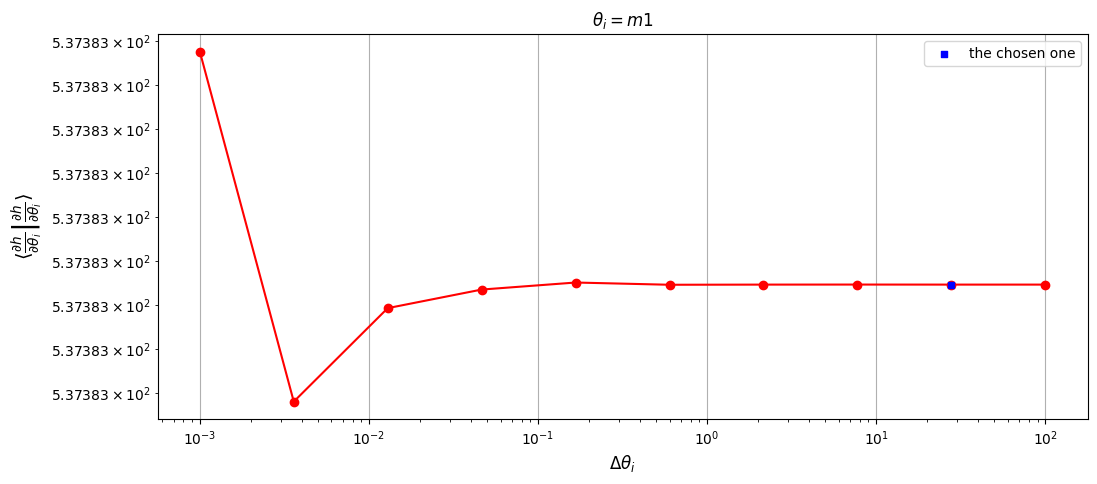

Gamma_ii for m2: 45249161576.00057
Gamma_ii for m2: 45249161573.51119
Gamma_ii for m2: 45249161599.04524
Gamma_ii for m2: 45249161504.50451
Gamma_ii for m2: 45249161724.0905
Gamma_ii for m2: 45249161514.70757
Gamma_ii for m2: 45249160723.4908
Gamma_ii for m2: 45249171905.547226
Gamma_ii for m2: 45249118453.420815
Gamma_ii for m2: 45249211305.79194
[np.float64(5.501493942088377e-11), np.float64(5.642988529611063e-10), np.float64(2.089336690316149e-09), np.float64(4.85281898137032e-09), np.float64(4.627332748980578e-09), np.float64(1.7485777887059496e-08), np.float64(2.471217915400373e-07), np.float64(1.181285475571448e-06), np.float64(2.0520218683321535e-06)]
0


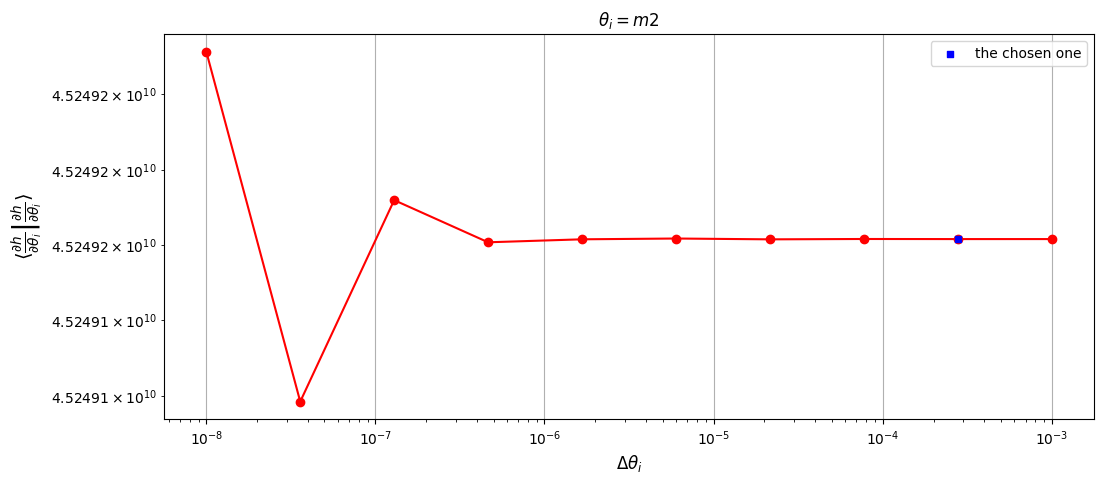

Gamma_ii for a: 2536876692901.991
Gamma_ii for a: 2536877281552.559
Gamma_ii for a: 2536879499798.5815
Gamma_ii for a: 2536909278308.4385
Gamma_ii for a: 2536903855807.715
Gamma_ii for a: 2536735048299.071
Gamma_ii for a: 2537409801340.764
Gamma_ii for a: 2536357466749.511
Gamma_ii for a: 2534064152475.1035
Gamma_ii for a: 2534291146676.828
[np.float64(2.320374628097272e-07), np.float64(8.743994433464647e-07), np.float64(1.1738105935262029e-05), np.float64(2.1374482565506466e-06), np.float64(6.65451871913985e-05), np.float64(0.00026592198128060383), np.float64(0.0004148999520172357), np.float64(0.0009049945606814096), np.float64(8.956910969849021e-05)]
0


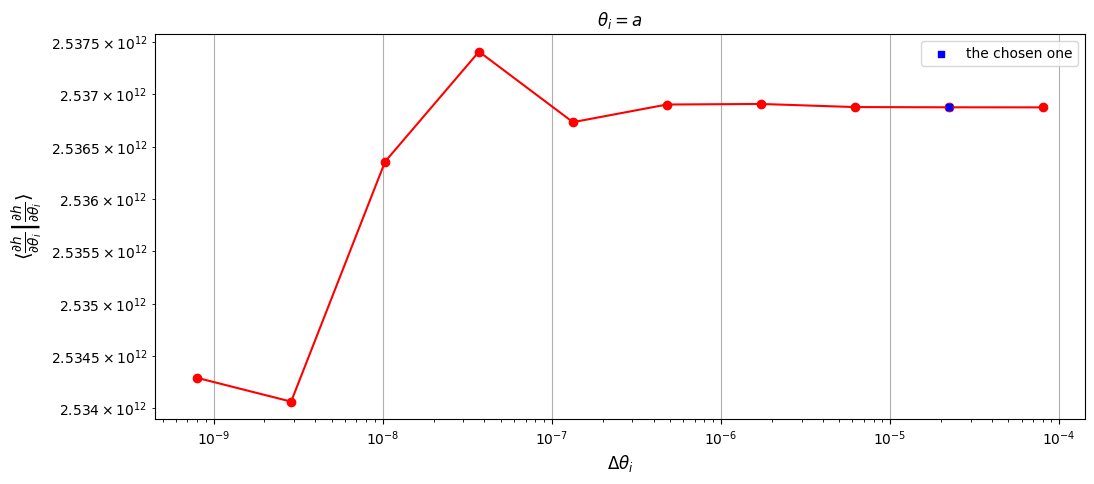

Gamma_ii for p0: 20567075849285.28
Gamma_ii for p0: 20567075184587.53
Gamma_ii for p0: 20567078442468.2
Gamma_ii for p0: 20567087922897.2
Gamma_ii for p0: 20567048199220.145
Gamma_ii for p0: 20567049984316.805
Gamma_ii for p0: 20566635588617.78
Gamma_ii for p0: 20567553904886.89
Gamma_ii for p0: 20566164042871.82
Gamma_ii for p0: 20565407936240.504
[np.float64(3.231853552507594e-08), np.float64(1.5840269570040987e-07), np.float64(4.6095144998361693e-07), np.float64(1.931423346214248e-06), np.float64(8.679400602018556e-08), np.float64(2.014892991310533e-05), np.float64(4.464878387367111e-05), np.float64(6.758003155926567e-05), np.float64(3.676594374692611e-05)]
0


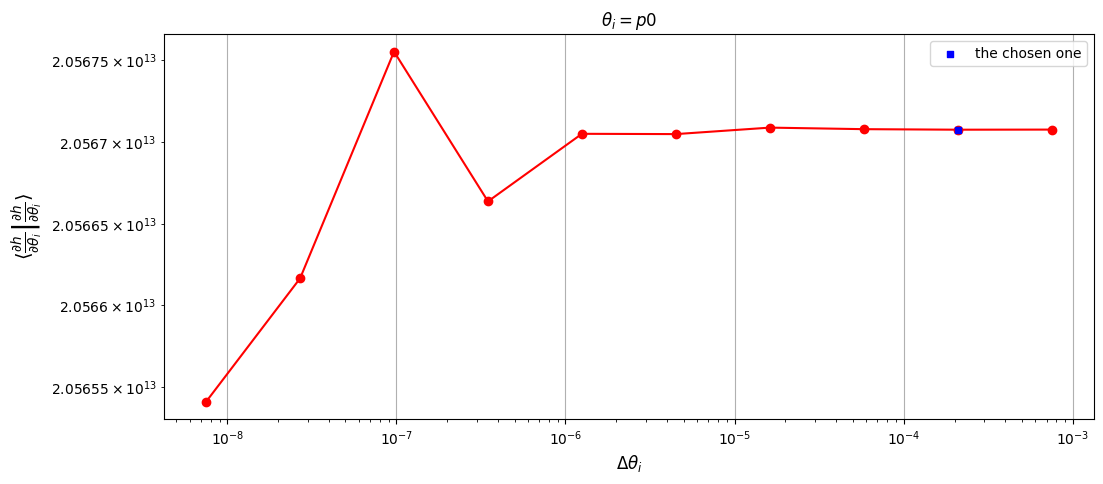

Gamma_ii for e0: 335337296711408.6
Gamma_ii for e0: 335337307146527.75
Gamma_ii for e0: 335337101152896.3
Gamma_ii for e0: 335336549864339.8
Gamma_ii for e0: 335335602932409.06
Gamma_ii for e0: 335339889710661.94
Gamma_ii for e0: 335335308058014.5
Gamma_ii for e0: 335358084361562.75
Gamma_ii for e0: 334979186955112.75
Gamma_ii for e0: 335331886197885.3
[np.float64(3.1118276739904485e-08), np.float64(6.14288221402551e-07), np.float64(1.64398589036305e-06), np.float64(2.823833563956123e-06), np.float64(1.2783383022442452e-05), np.float64(1.3662899603297526e-05), np.float64(6.791636942824963e-05), np.float64(0.0011311073081706783), np.float64(0.0010517915453003726)]
0


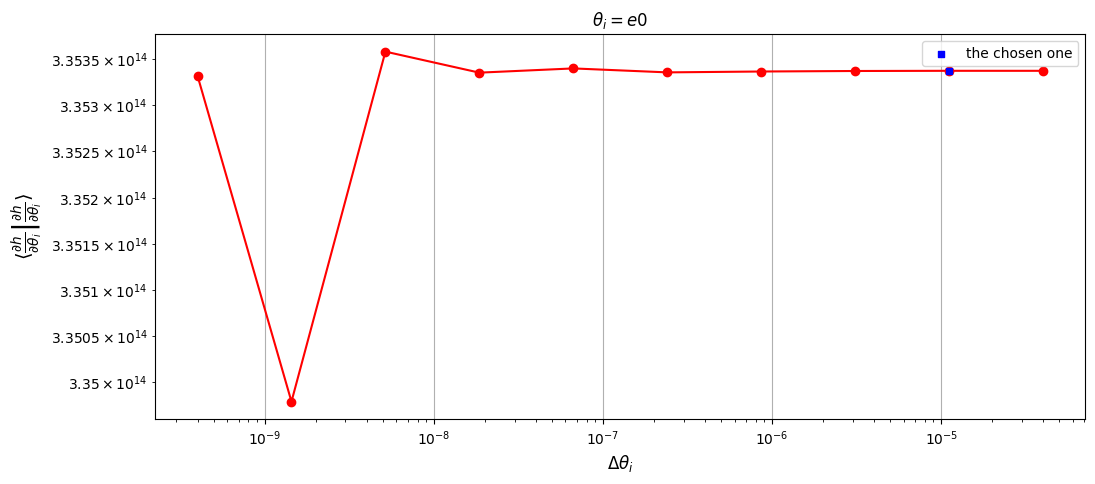

Gamma_ii for qS: 16130.578703302637
Gamma_ii for qS: 16130.578725470608
Gamma_ii for qS: 16130.57872547125
Gamma_ii for qS: 16130.57872547163
Gamma_ii for qS: 16130.578725469171
Gamma_ii for qS: 16130.57872546729
Gamma_ii for qS: 16130.57872543545
Gamma_ii for qS: 16130.578725478046
Gamma_ii for qS: 16130.578725792971
Gamma_ii for qS: 16130.578726020107
[np.float64(1.3742824412937424e-09), np.float64(3.980658539161796e-14), np.float64(2.3568204948577782e-14), np.float64(1.52460349715225e-13), np.float64(1.1660059290352147e-13), np.float64(1.97386535608053e-12), np.float64(2.6406538530173516e-12), np.float64(1.952349501950183e-11), np.float64(1.4081043940784175e-11)]
2


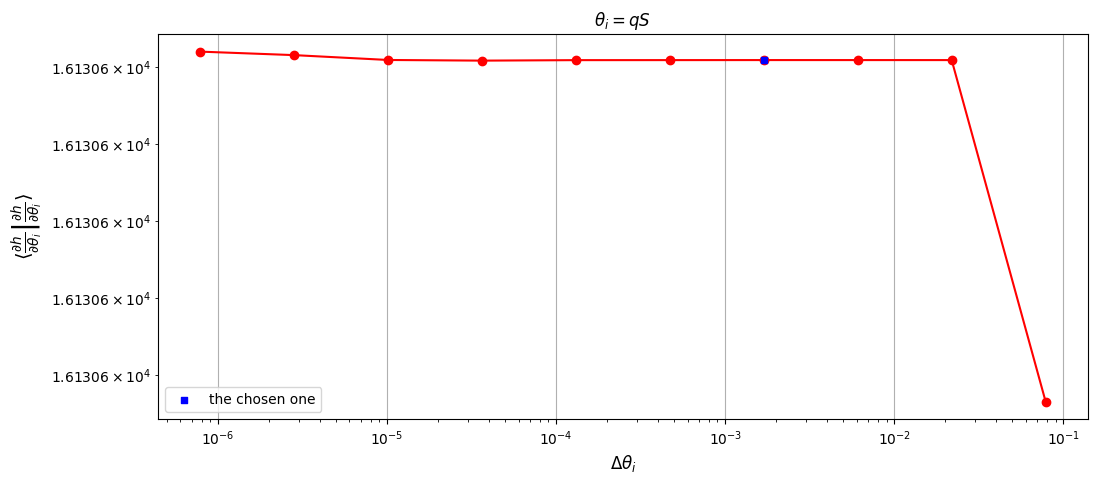

Gamma_ii for phiS: 310526.5251724281
Gamma_ii for phiS: 310526.5251677245
Gamma_ii for phiS: 310526.52516772435
Gamma_ii for phiS: 310526.52516772435
Gamma_ii for phiS: 310526.52516772435
Gamma_ii for phiS: 310526.5251677243
Gamma_ii for phiS: 310526.5251677247
Gamma_ii for phiS: 310526.52516772464
Gamma_ii for phiS: 310526.5251677148
Gamma_ii for phiS: 310526.5251677346
[np.float64(1.5147132609344772e-11), np.float64(5.623448194838857e-16), np.float64(0.0), np.float64(0.0), np.float64(1.8744827316129525e-16), np.float64(1.312137912129065e-15), np.float64(1.8744827316129503e-16), np.float64(3.167875816425987e-14), np.float64(6.373241287483827e-14)]
2


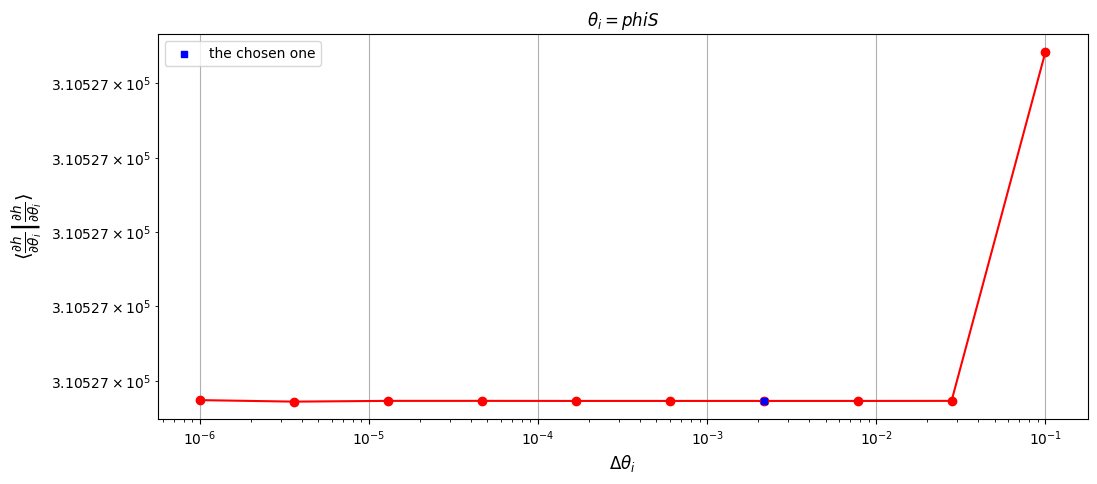

stable deltas: {'m1': 27.825594022071243, 'm2': 0.0002782559402207126, 'a': 2.2260475217657015e-05, 'p0': 0.00020869195516553445, 'e0': 1.1130237608828506e-05, 'qS': 0.0016920890487107918, 'phiS': 0.002154434690031882, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 73.26091623306274 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 7.817246198654175 seconds


In [5]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])

In [7]:
chi2=0
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)
waveform_true

[0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


array([[ 7.59731776e-22,  6.60914771e-22,  5.20147403e-22, ...,
         6.04820826e-22,  3.99769190e-22,  1.71340558e-22],
       [-2.23147815e-22, -4.10767987e-22, -5.56269144e-22, ...,
        -5.69291856e-22, -7.11607124e-22, -7.80367190e-22]],
      shape=(2, 1577908))

In [8]:
def inner_prod_without_phase(a, b, PSD, dt, window=None, fmin=None, fmax=None, use_gpu=False):

    if use_gpu:
        xp = cp
    else:
        xp = np

    # print("fmin: {}, fmax: {}".format(fmin, fmax))

    # frequency cutoff mask
    if (fmin != None) or (fmax != None):

        length = len(a[0])
        freq = xp.fft.rfftfreq(length) / dt

        if use_gpu:
            freq = freq.get()  # convert to numpy

        if fmin != None:
            mask_min = freq > fmin

        if fmax != None:
            mask_max = freq < fmax

        if (fmin != None) and (fmax == None):
            freq_mask = mask_min
        elif (fmin == None) and (fmax != None):
            freq_mask = mask_max
        else:
            freq_mask = xp.logical_and(mask_min, mask_max)

    else:
        length = len(a[0])
        
        freq = xp.fft.rfftfreq(length) / dt

        freq_mask = np.full(len(freq), True, dtype=bool)

    freq_mask = freq_mask[1:]  # skip the first element corresponding to f = 0.0

    a = xp.atleast_2d(a)
    b = xp.atleast_2d(b)
    PSD = xp.atleast_2d(
        xp.asarray(PSD)
    )  # handle passing the same PSD for multiple channels

    N = a.shape[1]

    df = (N * dt) ** -1

    if window is not None:
        window = xp.atleast_2d(xp.asarray(window))
        a_in = a * window
        b_in = b * window
    else:
        a_in, b_in = a, b

    if xp.iscomplexobj(a_in):
        a_fft_plus = (dt * xp.fft.rfft(a_in.real, axis=-1)[:, 1:])[:, freq_mask]
        a_fft_cross = (dt * xp.fft.rfft(a_in.imag, axis=-1)[:, 1:])[:, freq_mask]

        b_fft_plus = (dt * xp.fft.rfft(b_in.real, axis=-1)[:, 1:])[:, freq_mask]
        b_fft_cross = (dt * xp.fft.rfft(b_in.imag, axis=-1)[:, 1:])[:, freq_mask]

        inner_prod = (
            4
            * df
            * (
                xp.abs(a_fft_plus.conj() * b_fft_plus + a_fft_cross * b_fft_cross.conj()
                / PSD[:, freq_mask])
            ).sum()
        )

    else:
        a_fft = (dt * xp.fft.rfft(a_in, axis=-1)[:, 1:])[:, freq_mask]
        b_fft = (dt * xp.fft.rfft(b_in, axis=-1)[:, 1:])[:, freq_mask]

        # Compute inner products over given channels
        inner_prod = 4 * df * xp.abs(((a_fft.conj() * b_fft)) / PSD[:, freq_mask]).sum()

    if use_gpu:
        inner_prod = inner_prod.get()

    return inner_prod


In [19]:
chi2=0
deviation_included=False
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args, dt=dt, T=T,use_gpu=use_gpu))

    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    return -0.5 * diff_inner * 800000

def loglike_calc_snr(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args, dt=dt, T=T))
    diff_inner=inner_prod_without_phase(waveform_temp,waveform_true,PSD,dt,use_gpu=use_gpu)/np.sqrt(inner_prod_without_phase(waveform_temp,waveform_temp,PSD,dt,use_gpu=use_gpu))
    return -0.5 * diff_inner 


In [20]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_ = params[i]
        m1_ = np.exp(logm1_)
        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_)
        log_likes[i] = loglike 
    return log_likes

n=5
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]


def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]


    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])

    
    return u

In [21]:
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]

ranges=[logm1lim, m2lim, alim, p0lim, e0lim, qSlim, phiSlim, Phi_phi0lim, Phi_r0lim]
ranges

[[np.float64(13.812567212371988), np.float64(13.81845390355656)],
 [np.float64(9.984835336065004), np.float64(10.015164663934996)],
 [np.float64(0.797779725494416), np.float64(0.8022202745055841)],
 [np.float64(7.486994217557862), np.float64(7.513005782442138)],
 [np.float64(0.39951120193902345), np.float64(0.4004887980609766)],
 [np.float64(0.6602210864071085), np.float64(0.910575240387788)],
 [np.float64(0.8433317165568631), np.float64(1.1566682834431368)],
 [np.float64(0.25101525084416176), np.float64(1.5489847491558382)],
 [np.float64(0.2088315319431344), np.float64(0.5911684680568656)]]

In [30]:
# def main():
    
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 9
n_seed = 100  # Number of initial processes
init_cov_list = [np.eye(ndim) * 1e-12] * n_seed
savepath = 'paris_1PA_vs_0PA__last'  # Directory to save results

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")
# sampler.prepare_lhs_samples(lhs_num=int(5e4), batch_size=50)
# x = np.linspace(0.49999, 0.50001, 2000)

# # Generate 99 random points in 11D
# external_lhs_points = np.random.choice(x, size=(99, 11))

# # Add the "true point" [0.5, 0.5, ..., 0.5] as the 100th point
# external_lhs_points = np.vstack([external_lhs_points, [0.5]*11])

#best value got so far
true_point = np.array([0.51740058, 0.51836276, 0.51861481, 0.48262964, 0.48210917, 0.49985051,
 0.49996388, 0.50005352, 0.4994075 ])
# Generate 99 points around it with tiny Gaussian noise ~1e-10
scatter = 1.0e-7
points = true_point + np.random.randn(99, 9) * scatter
# Add the original point as the 100th row
external_lhs_points = np.vstack([points, true_point])
print("Shape of points array:", external_lhs_points.shape)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external_lhs_log_densities", external_lhs_log_densities)


# external_lhs_points = np.vstack(external_lhs_points)
# external_lhs_log_densities = np.concatenate(external_lhs_log_densities)

sampler.run_sampling(
            num_iterations=int(5e4),
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.01
        )
#except Exception as exc:
 #       print(f"[WARN] PARIS sampling failed: {exc}")
    
# Gt results
print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in[0:9]):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")




Problem dimension: 9
Number of processes: 100
Save path: paris_1PA_vs_0PA__last
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...
Shape of points array: (100, 9)
true points in corrrect space [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]
external_lhs_log_densities [ -150.09238646  -100.80932949   -77.94946209   -78.90878616
  -116.93415974   -77.14371668  -234.99314129   -82.15258431
  -102.96601027  -573.66493899  -142.03967013  -208.90932165
  -512.6360178   -126.78845867   -81.86407209  -335.24699234
  -189.13169854  -103.0027956  -1085.79872896  -148.95744157
  -639.06794561   -78.55700327  -536.54779601  -270.67811091
  -119.38864532   -74.33068946 -1163.86150598 -1292.75220984
  -277.52658547  -273.6742872   -122.71225335  -159.00501589
   -94.04377037  -105.02867869 -1049.42405877   -90.51581161
   -75.73977213   -79.07893755  -131.93699718  -334.84886704
   -99.329777

Sampling:   0%|          | 0/49999 [00:00<?, ?it/s]

Value error in sampling: probabilities contain NaN


ValueError: probabilities contain NaN

In [31]:
best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
print(np.max(external_lhs_log_densities))
print(best_fit_tn)
prior_transform(np.array([best_fit_tn]))

-74.12945849205347
[0.5174005  0.51836271 0.51861493 0.48262964 0.48210911 0.49985049
 0.49996381 0.50005338 0.4994075 ]


array([[13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251,
         0.78536073,  0.99998866,  0.90006928,  0.39977347]])

#

# -0.39
## [13.81565113,10.0007212,  0.80011218,  7.49937491,  0.39997721,  0.78593775,1.00200384,  0.90623999,  0.40153853]

# [-0.00025698] (best point (confif))
## [13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251,  0.78536074,0.99998868 , 0.90006948,  0.39977346]



#

In [34]:
#print(log_density([params_truth_in]))
log_density([[13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251,  0.78536074,0.99998868 , 0.90006948,  0.39977346]])

array([-205.58778769])

In [31]:
inverse_prior_transform(np.array([[13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251,  0.78536074,
  0.99998868 , 0.90006948,  0.39977346]]))

array([[0.51740061, 0.51836275, 0.51861482, 0.48262965, 0.48210918,
        0.49985052, 0.49996387, 0.50005353, 0.49940749]])

In [ ]:
import corner

param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim]

# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)

labels = [
    "logm1", "m2", "a", "p0", "e0","qS", "phiS", "Phi_phi0", "Phi_r0",]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=25,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [16]:
ls

SuperKludge_r/
multi_inference_GWs/
packages_for_multi_inference/
paris_runs/
paris_try_100_batch100000_stop0_01_cov_08/
paris_try_100_batch100000_stop0_01_cov_08_resume/
parismc/
run_for_jupyter.sh*
sampler_flags.json


In [ ]:
def summarize(sampler: Sampler) -> None:
    print("Sampler State")
    print("-------------")
    print(f"ndim: {sampler.ndim}")
    print(f"n_proc: {sampler.n_seed}")
    print(f"current_iter: {getattr(sampler, 'current_iter', None)}")
    print(f"savepath: {getattr(sampler, 'savepath', '(unset)')}")
    
state_path = 'paris_try_100_batch100000_stop0_01_cov__10/sampler_state.pkl'
if not os.path.isfile(state_path):
    print(f"Sampler state not found at: {state_path}")
    print("Please run the multimodal example first:")
    print("  python examples/multimodal_example.py")
    raise FileExistsError(f"State file not found: {state_path}")


sampler = Sampler.load_state(state_path)

# Optionally, rebind the functions to the wrappers for clarity
# (unpickling may already have set them to these wrappers).
try:
        sampler.log_density_func_original = log_density
        if hasattr(sampler, "prior_transform") and sampler.prior_transform is not None:
            sampler.prior_transform = prior_transform
        # If prior_transform was set, ensure transformed log-density hook is in place
        if getattr(sampler, "prior_transform", None) is not None:
            sampler.log_density_func = sampler.transformed_log_density_func
        else:
            sampler.log_density_func = sampler.log_density_func_original
        print("Rebound functions after loading state.")
except Exception:
        # Keep going even if attributes differ in older states
        pass

print("Loaded state. Summary before resume:")
summarize(sampler)

    # Continue sampling
print("\nResuming sampling...")
sampler.run_sampling(
num_iterations=int(1e4),
        savepath="paris_try_100_batch100000_stop0_01_cov__10",
        print_iter=200,
        stop_dlogZ=0.01,
    )

print("\nResume completed. Summary after resume:")
summarize(sampler)

    # Optional: quick analysis similar to load_sampler_example
try:
        import numpy as np
        samples, weights = sampler.get_samples_with_weights(flatten=True)
        ess = 1.0 / (weights ** 2).sum()
        wmean = (samples * weights[:, None]).sum(axis=0) / weights.sum()
        print("\nQuick analysis")
        print("--------------")
        print(f"Total samples: {len(samples)}")
        print(f"Effective sample size (ESS): {ess:.1f}")
        print(f"Weighted mean (first 5 dims): {wmean[:5]}")
except Exception as e:
        print(f"Analysis skipped: {e}")


Sampler state not found at: paris_try_100_batch100000_stop0_01_cov__10/sampler_state.pkl
Please run the multimodal example first:
  python examples/multimodal_example.py


FileExistsError: State file not found: paris_try_100_batch100000_stop0_01_cov__10/sampler_state.pkl

In [ ]:
print(f"Weighted mean (first 5 dims): {wmean[:]}")

In [ ]:
import corner

param_ranges= [logm1lim,m2lim,alim,p0lim,e0lim,qSlim,phiSlim,Phi_phi0lim,Phi_r0lim]

# scale ranges → must become list of (min, max) tuples
# param_ranges = [(l[0] * n_scaling, l[1] * n_scaling) for l in param_ranges]
print(param_ranges)
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)
labels = [
    "logm1", "m2", "a", "p0", "e0",
    "qS", "phiS", "Phi_phi0", "Phi_r0",
    "dev0p", "dev0e"
]

fig = corner.corner(
    samples_,
    weights=weights_,
    labels=labels,
    truths=params_truth_in,
    truth_color="red",
    color="green",
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=20,
    plot_datapoints=False,
    hist_kwargs={"density": True, "linewidth": 2.5},
    linewidths=2.5,
    fill_contours=True,
    range=param_ranges)

fig.show()


In [ ]:
n=0.01
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
logm_range=np.linspace(logm1lim[0],logm1lim[1],1000)
val_m=[]

for i in logm_range:
    loglike=log_density(np.array([[i, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e]]))
    val_m.append(loglike)


In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=params_truth_in[0],color='red')
plt.xlabel('logm1')
plt.ylabel('loglike')
plt.title('loglike vs logm1 (0.01 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=qS,color='red')
plt.xlabel('qS')
plt.ylabel('loglike')
plt.title('loglike vs qS (1 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=0,color='red')
plt.xlabel('dev_0_p')
plt.ylabel('loglike')
plt.title('loglike vs dev_0_p (1 std)')

In [ ]:
plt.plot(logm_range,val_m)
plt.axvline(x=params_truth_in[4],color='red')
plt.xlabel('e0')
plt.ylabel('loglike')
plt.title('loglike vs e0 (1 std)')

In [ ]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')
covariance= np.linalg.inv(fisher_)
fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in[i], color='k', linestyle='-', lw=2, label='True')
    ax.legend(fontsize=10)


plt.tight_layout()
plt.show()


In [ ]:
from stableemrifisher.plot import CovEllipsePlot
import numpy as np
import matplotlib.pyplot as plt

pars_list = params_truth_in
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

# --- build wave_params dict (same as original) ---
wave_params = {param_names[i]: params_truth_in[i] for i in range(len(pars_list))}

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

# --- create subplots grid ---
fig, axs = plt.subplots(len(covariance), len(covariance), figsize=(20,20))

# --- Fisher covariance ellipse corner plot ---
fig, axs = CovEllipsePlot(
    covariance,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs,
    line_kwargs=line_kwargs
)

# === ADD TRUE PARAMETER LINES (existing behavior) ===
for i in range(len(param_names)):
    ax = axs[i, i]
    ax.axvline(params_truth_in[i], color='k', linestyle='-', lw=2, label='True')
    ax.legend(fontsize=10)

# === ADD 99% CONDITIONAL POSTERIOR LINES ON DIAGONAL ===
for i in range(len(param_names)):

    theta = params_truth_in.copy()  # reference conditioning point
    grid = np.linspace(param_ranges[i][0], param_ranges[i][1], 2000)
    logP = []

    for x in grid:
        theta[i] = x
        lp = log_density(np.array([theta]))
        logP.append(lp[0])


    logP = np.array(logP)
    P = np.exp(logP - logP.max())  # unnormalized conditional posterior
    P /= np.trapezoid(P, grid)         # normalize

    # build CDF and extract 0.5% and 99.5% quantiles
    cdf = np.cumsum(P)
    cdf /= cdf[-1]
    low_99  = grid[np.searchsorted(cdf, 0.005)]
    high_99 = grid[np.searchsorted(cdf, 0.995)]

    # plot the 99% lines on the diagonal subplot
    ax = axs[i, i]
    ax.axvline(low_99,  linestyle="--", lw=2, label="0.5% (conditional)")
    ax.axvline(high_99, linestyle="--", lw=2, label="99.5% (conditional)")
    ax.legend(fontsize=9)

    print(f"{param_names[i]:10s} 99% conditional interval → [{low_99:.6f}, {high_99:.6f}]")

plt.tight_layout()
plt.show()
